## 1. Install and import

In [57]:
!pip install kagglehub
import os
import random
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## 2. Download dataset

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debeshjha1/surgical-instrument-classification")

print("Downloaded dataset path:", path)


Downloaded dataset path: /Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1


## 3. Check folder structure
*Run this to see where the class folders are:*

In [59]:
root_path = Path(path)

for item in root_path.iterdir():
    print(item)

/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data


In [60]:
from pathlib import Path

data_dir = Path(path) / "Instrument Data"

print(data_dir)

/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data


In [61]:
for item in data_dir.iterdir():
    print(item.name)

Clip
Chain
No Instrument
White Tube
Doubt
Hook
Hold


## 4. Set device and seed

In [62]:
device = torch.device( "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

mps


## 5. Define transforms

*Train set gets augmentation.* </b>
*Validation/test get only resize + tensor.*

In [63]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## 6. Load full dataset first

In [64]:
full_dataset = datasets.ImageFolder(root=data_dir)

print("Classes:", full_dataset.classes)
print("Class to index:", full_dataset.class_to_idx)
print("Total images:", len(full_dataset))

Classes: ['Chain', 'Clip', 'Doubt', 'Hold', 'Hook', 'No Instrument', 'White Tube']
Class to index: {'Chain': 0, 'Clip': 1, 'Doubt': 2, 'Hold': 3, 'Hook': 4, 'No Instrument': 5, 'White Tube': 6}
Total images: 1315


## 7. Split into train / val / test

In [65]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 920
Val: 197
Test: 198


## verify augmentation

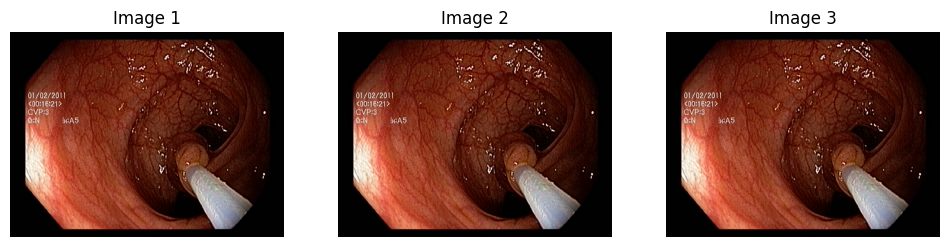

In [96]:
import matplotlib.pyplot as plt

img1, _ = train_dataset[0]
img2, _ = train_dataset[0]
img3, _ = train_dataset[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img3)
plt.title("Image 3")
plt.axis("off")

plt.show()

## 8. Apply different transforms to split datasets
*random_split gives subsets, so we wrap them to apply transforms properly.*

In [ ]:
class CustomSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label   

In [ ]:
train_dataset = CustomSubset(train_dataset, transform=train_transform)
val_dataset = CustomSubset(val_dataset, transform=test_transform)
test_dataset = CustomSubset(test_dataset, transform=test_transform)

In [ ]:
train_dataset

## 9. Handle imbalance with weighted sampler
*This is important because your classes are imbalanced.*

In [ ]:
# labels from original split indices
train_indices = train_dataset.subset.indices
train_labels = [full_dataset.samples[i][1] for i in train_indices]

class_count = np.bincount(train_labels)
print("Class counts in train split:", class_count)

class_weights = 1. / class_count
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts in train split: [ 88  32  17  23 120  12 628]


## 10. Create DataLoaders

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)   # [batch_size, 3, 224, 224]
print("Label batch shape:", labels.shape)   # [batch_size]

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## 11. Load pretrained ResNet50, freeze all layers, change classifier

In [ ]:
import torchvision.models as models
import torch.nn as nn

import torchvision.models as models
resnet50 = models.resnet50(pretrained=True)
print(resnet50)


/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/abroadhub/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
resnet50.fc.in_features

2048

In [ ]:
resnet50.fc.out_features

1000

In [ ]:
# Freezing all layers
for param in resnet50.parameters():
    param.requires_grad = False

In [ ]:

# Unfreeze only the new FC layer
for param in resnet50.fc.parameters():
    param.requires_grad = True

In [ ]:
# replace fc (final layer)
resnet50.fc = nn.Linear(resnet50.fc.in_features, 7)
for param in resnet50.fc.parameters():
    param.requires_grad = True

In [ ]:
resnet50 = resnet50.to(device)

In [ ]:
learning_rate = 0.0001
epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.fc.parameters(), lr=learning_rate)

# training loop
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet50(batch_features)

    loss = criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 1.0187712866684486
Epoch: 2 , Loss: 1.0397702928247123
Epoch: 3 , Loss: 1.0084624783746128
Epoch: 4 , Loss: 1.0006771416499698
Epoch: 5 , Loss: 0.9379415943704802
Epoch: 6 , Loss: 0.9404981156875347
Epoch: 7 , Loss: 0.9518128016899372
Epoch: 8 , Loss: 0.911793458050695
Epoch: 9 , Loss: 0.9186174211830929
Epoch: 10 , Loss: 0.9330889459314018
Epoch: 11 , Loss: 0.9290109441198152
Epoch: 12 , Loss: 0.9318117129391638
Epoch: 13 , Loss: 0.9097198145142917
Epoch: 14 , Loss: 0.8690003937688368
Epoch: 15 , Loss: 0.8962243569308314


In [ ]:
# evaluate the TEST data
total = 0
correct = 0
with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = resnet50(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.42424242424242425


## Install OpenCV 

In [67]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## Part-1: Create a Fake Video from Your Images (10-15 lines)

*cv2 (OpenCV):  It can read images, convert colors, and simulate video processing.*</br>

*time: This is a stopwatch! It measures how many milliseconds each frame takes.*</br>

*Pathlib: Helps us find files in your dataset folders.*</br>

*random: To shuffle images so our video isn't predictable.*</br>

*matplotlib: To draw graphs so you can SEE your results visually.*</br>

*transforms: The same preprocessing you used for training (resize, normalize).*<br/>

In [72]:
import cv2
import time
import numpy as np
from pathlib import Path
import random
import matplotlib.pyplot as plt
from torchvision import transforms

## Part-2: Create a Video from Your Images

In [80]:
print("\n STEP 1: Creating a fake video from your images")
print("="*50)

# Get all images from your dataset
data_path = Path(data_dir)
print(data_path)
all_images = []
all_labels = []

# Take 5 images from each class
for class_idx, class_name in enumerate(full_dataset.classes):
    class_folder = data_path / class_name
    print(class_folder)
    images = list(class_folder.glob('*.jpg')) + list(class_folder.glob('*.png'))
    selected = random.sample(images, min(5, len(images)))
    for img in selected:
        all_images.append(img)
        all_labels.append(class_idx)
    print(f"  Class '{class_name}': added {len(selected)} images")

print(f"\nTotal frames in our fake video: {len(all_images)}")


 STEP 1: Creating a fake video from your images
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data/Chain
  Class 'Chain': added 5 images
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data/Clip
  Class 'Clip': added 5 images
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data/Doubt
  Class 'Doubt': added 5 images
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data/Hold
  Class 'Hold': added 5 images
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrument-classification/versions/1/Instrument Data/Hook
  Class 'Hook': added 5 images
/Users/abroadhub/.cache/kagglehub/datasets/debeshjha1/surgical-instrume

## Why are we doing this ? 
*A real video is just a sequence of images (frames). Since we don't have a real surgical video, we're creating one by taking images from your dataset and putting them in random order. This simulates what a real video would look like - different instruments appearing one after another.*

## Part-3: Set Up Image Preprocessing

In [83]:
print("\n STEP 2: Setting up image preprocessing")
print("="*50)

# Same transform you used for testing your model
transform = transforms.Compose([
    transforms.ToPILImage(),     # Convert numpy array to PIL image
    transforms.Resize((224, 224)),  # Resize to what your model expects
    transforms.ToTensor(),        # Convert to PyTorch tensor
    transforms.Normalize(         # Normalize (same as training)
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])
print("Transform ready - will resize images to 224x224 and normalize them")


 STEP 2: Setting up image preprocessing
Transform ready - will resize images to 224x224 and normalize them


## WHY this transform?

*Your ResNet50 model was trained on images that are:*<br/>

<ul>
<li>224x224 pixels in size</li>

<li>Normalized with specific mean/std values</li>

<li>Converted to tensors</li>
</ul>

*This transform makes sure every image from your "video" is in the exact format your model expects. Without this step, your model wouldn't recognize the images!*

## Step 4: Prepare Your Model

In [85]:
print("\n🧠 STEP 3: Preparing your trained model")
print("="*50)

model = resnet50
model.eval()
model.to(device)

print(f"Model ready on {device}")
print("Model set to evaluation mode (this turns off dropout/batch norm training behavior)")


🧠 STEP 3: Preparing your trained model
Model ready on mps
Model set to evaluation mode (this turns off dropout/batch norm training behavior)


## WHY model.eval()?
<ul>When you train a model, it behaves differently (dropout layers randomly turn off neurons, batch norm tracks statistics). For testing/prediction, we want consistent behavior. model.eval() switches to prediction mode</ul>

## Step 5: Process Frames and Measure Latency

In [88]:
print("\n STEP 4: Processing each frame and measuring time")
print("="*60)

print(f"{'Frame #':<8} {'Time (ms)':<12} {'Predicted':<20} {'Actual':<20} {'Correct?'}")
print("-"*60)

# Store time for each frame
latencies = [] 

# Count correct predictions
correct_predictions = 0  

for i, (img_path, true_label) in enumerate(zip(all_images, all_labels)):
    # Load the image
    img = cv2.imread(str(img_path))
    
    # START THE STOPWATCH 
    start_time = time.time()
    
    # Preprocess the image
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_tensor = transform(img_rgb).unsqueeze(0).to(device)
    
    # Run your model (this is where the "thinking" happens)
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        pred_class = predicted.item()
    
    # STOP THE STOPWATCH 
    end_time = time.time()
    
    # Calculate how long this frame took (in milliseconds)
    latency = (end_time - start_time) * 1000
    latencies.append(latency)
    
    # Check if prediction was correct
    is_correct = (pred_class == true_label)
    if is_correct:
        correct_predictions += 1
    
    # Show result
    correct_mark = "Right" if is_correct else "WRONG"
    print(f"{i+1:<8} {latency:<12.1f} {full_dataset.classes[pred_class]:<20} "
          f"{full_dataset.classes[true_label]:<20} {correct_mark}")


 STEP 4: Processing each frame and measuring time
Frame #  Time (ms)    Predicted            Actual               Correct?
------------------------------------------------------------
1        68.0         Clip                 Chain                WRONG
2        15.7         Chain                Chain                Right
3        15.3         Chain                Chain                Right
4        14.1         Chain                Chain                Right
5        18.7         Chain                Chain                Right
6        15.6         Clip                 Clip                 Right
7        15.0         Clip                 Clip                 Right
8        15.3         Clip                 Clip                 Right
9        19.7         Clip                 Clip                 Right
10       14.6         Clip                 Clip                 Right
11       14.5         Doubt                Doubt                Right
12       15.5         Clip                 Do

* Q1 = How long does it take to process ONE frame? (latency)*

* Q2 = Can we keep up with a real video? (FPS calculation later)*

*The start_time and end_time are like a stopwatch for each frame. The difference tells us exactly how many milliseconds your system needs to:*
<ul>
<li>Load the image</li>

<li>Preprocess it</li>

<li>Run it through the model</li>

<li>Get a prediction</li>
</ul>

## Step 6: Calculate the Metrics 


In [89]:
print("\n" + "="*60)
print("STEP 5: Calculating Phase-1 Metrics")
print("="*60)

# Calculate average latency
avg_latency = sum(latencies) / len(latencies)

# Calculate FPS (Frames Per Second)
# If one frame takes X milliseconds, then in 1000ms (1 second) we can process:
# 1000 / X frames
fps = 1000 / avg_latency

print(f"\n METRIC 1: THROUGHPUT (FPS)")
print(f"   Your system can process {fps:.1f} frames per second")
print(f"   This means: In one second, you can analyze {fps:.1f} video frames")

print(f"\n METRIC 2: PER-FRAME LATENCY")
print(f"   Average time per frame: {avg_latency:.1f} milliseconds")
print(f"   Fastest frame: {min(latencies):.1f} ms")
print(f"   Slowest frame: {max(latencies):.1f} ms")

print(f"\n  EXTRA: ACCURACY ON THESE FRAMES")
acc = (correct_predictions / len(all_images)) * 100
print(f"   Your model got {correct_predictions}/{len(all_images)} correct = {acc:.1f}%")


STEP 5: Calculating Phase-1 Metrics

 METRIC 1: THROUGHPUT (FPS)
   Your system can process 61.9 frames per second
   This means: In one second, you can analyze 61.9 video frames

 METRIC 2: PER-FRAME LATENCY
   Average time per frame: 16.1 milliseconds
   Fastest frame: 13.2 ms
   Slowest frame: 68.0 ms

  EXTRA: ACCURACY ON THESE FRAMES
   Your model got 26/35 correct = 74.3%


<ul>
<li>FPS (Throughput): Real surgical videos play at 30 fps. If your FPS is lower than 30, you are falling behind. If it's higher, you are keeping up!</li>

<li>Average Latency: This tells you how responsive your system is. Lower is better.</li>

<li>Min/Max Latency: Shows if some frames take much longer than others (inconsistent performance)</li>
</ul>

## Step 7: Visualize Your Results


 STEP 6: Visualizing the results


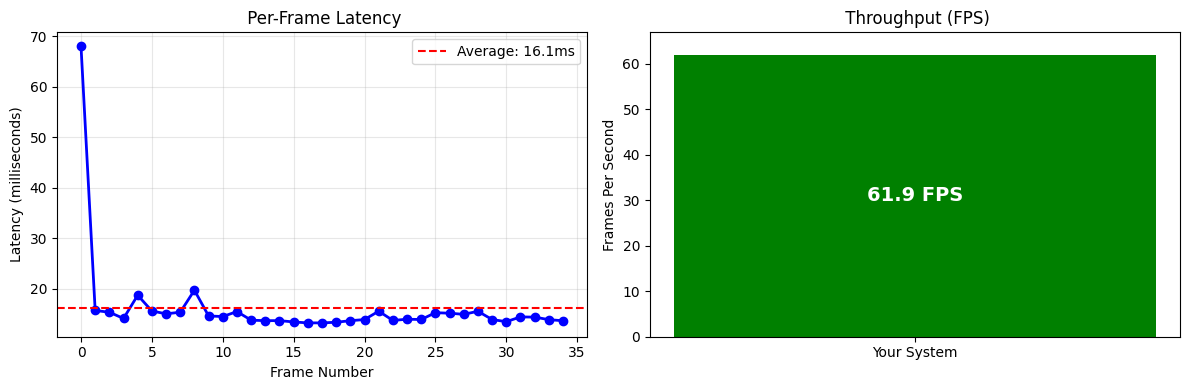

In [90]:
print("\n STEP 6: Visualizing the results")
print("="*60)

# Create two graphs side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Latency per frame
ax1.plot(latencies, marker='o', linestyle='-', color='blue', linewidth=2)
ax1.axhline(y=avg_latency, color='red', linestyle='--', 
            label=f'Average: {avg_latency:.1f}ms')
ax1.set_xlabel('Frame Number')
ax1.set_ylabel('Latency (milliseconds)')
ax1.set_title(' Per-Frame Latency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: FPS as a bar
ax2.bar(['Your System'], [fps], color='green', width=0.5)
ax2.set_ylabel('Frames Per Second')
ax2.set_title(' Throughput (FPS)')
ax2.set_ylim([0, max(30, fps+5)])
ax2.text(0, fps/2, f'{fps:.1f} FPS', ha='center', va='center', 
         color='white', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## Step 8: Understand What It All Means

In [92]:
print("\n" + "="*60)
print("STEP 7: Understanding Your Results")
print("="*60)

# Compare with real requirements
print(f"""
Your Results:
   FPS: {fps:.1f} frames per second
   Latency: {avg_latency:.1f} milliseconds per frame
   Accuracy: {acc:.1f}%

Real Surgical Video Requirements:
   • Videos play at 30 FPS
   • To keep up, you need FPS >= 30
   • For safety, latency should be < 50ms

What This Means For You:
   • {'You can keep up with 30 FPS video!' if fps >= 30 else f'⚠️ You process {30-fps:.1f} fewer frames than needed'}
   • {'Fast enough for surgery!' if avg_latency < 50 else '⚠️ Need to optimize speed'}
   
Simple Explanation:
   If a surgeon performs a 1-minute procedure (1800 frames at 30 FPS):
   • Your system would process {fps*60:.0f} frames
   • You would miss {(30-fps)*60:.0f} frames if fps < 30
   • Those missed frames might contain critical moments!
""")


STEP 7: Understanding Your Results

Your Results:
   FPS: 61.9 frames per second
   Latency: 16.1 milliseconds per frame
   Accuracy: 74.3%

Real Surgical Video Requirements:
   • Videos play at 30 FPS
   • To keep up, you need FPS >= 30
   • For safety, latency should be < 50ms

What This Means For You:
   • You can keep up with 30 FPS video!
   • Fast enough for surgery!
   
Simple Explanation:
   If a surgeon performs a 1-minute procedure (1800 frames at 30 FPS):
   • Your system would process 3716 frames
   • You would miss -1916 frames if fps < 30
   • Those missed frames might contain critical moments!

